In [2]:
# On installe les outils dont on a besoin
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "seaborn"])

print("✅ Installation terminée !")

✅ Installation terminée !


In [3]:
import pandas as pd

# Charge le fichier CSV
df = pd.read_csv("data/dataset.csv", sep=";")

# Affiche les 5 premières lignes
df.head()

,"Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target"
0,"1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,..."
1,"1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,..."
2,"1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6..."
3,"1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,..."
4,"2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,..."


In [5]:
import pandas as pd

# On enlève sep=";" et on laisse pandas détecter automatiquement
df = pd.read_csv("data/dataset.csv")

print("Nombre d'étudiants :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre d'étudiants : 4424
Nombre de colonnes : 35


In [6]:
# Combien de lignes et de colonnes ?
print("Nombre d'étudiants :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

# Est-ce qu'il manque des données ?
print("\nValeurs manquantes :")
print(df.isnull().sum())

Nombre d'étudiants : 4424
Nombre de colonnes : 35

Valeurs manquantes :
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                           

In [7]:
# Combien d'étudiants dans chaque catégorie ?
print(df["Target"].value_counts())
print()

# En pourcentage
print(df["Target"].value_counts(normalize=True).mul(100).round(1))

Graduate    2209
Dropout     1421
Enrolled     794
Name: Target, dtype: int64

Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: Target, dtype: float64


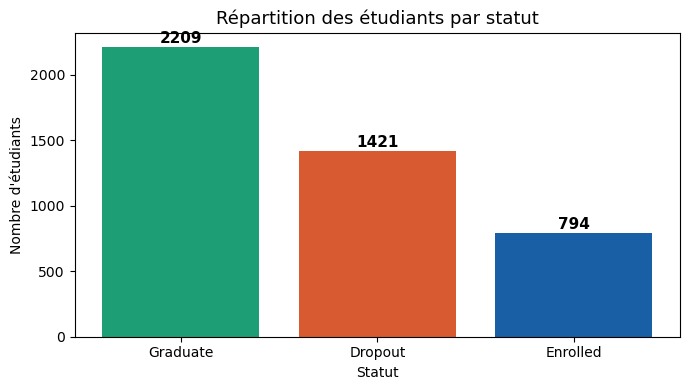

In [8]:
import matplotlib.pyplot as plt

# Compter les étudiants par statut
counts = df["Target"].value_counts()

# Créer le graphique
fig, ax = plt.subplots(figsize=(7, 4))

barres = ax.bar(
    counts.index,
    counts.values,
    color=["#1D9E75", "#D85A30", "#185FA5"]
)

# Ajouter les chiffres au-dessus des barres
for barre in barres:
    hauteur = barre.get_height()
    ax.text(
        barre.get_x() + barre.get_width() / 2,
        hauteur + 30,
        str(hauteur),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Répartition des étudiants par statut", fontsize=13)
ax.set_xlabel("Statut")
ax.set_ylabel("Nombre d'étudiants")

plt.tight_layout()
plt.savefig("figures/01_repartition.png")  # sauvegarde dans ton dossier
plt.show()

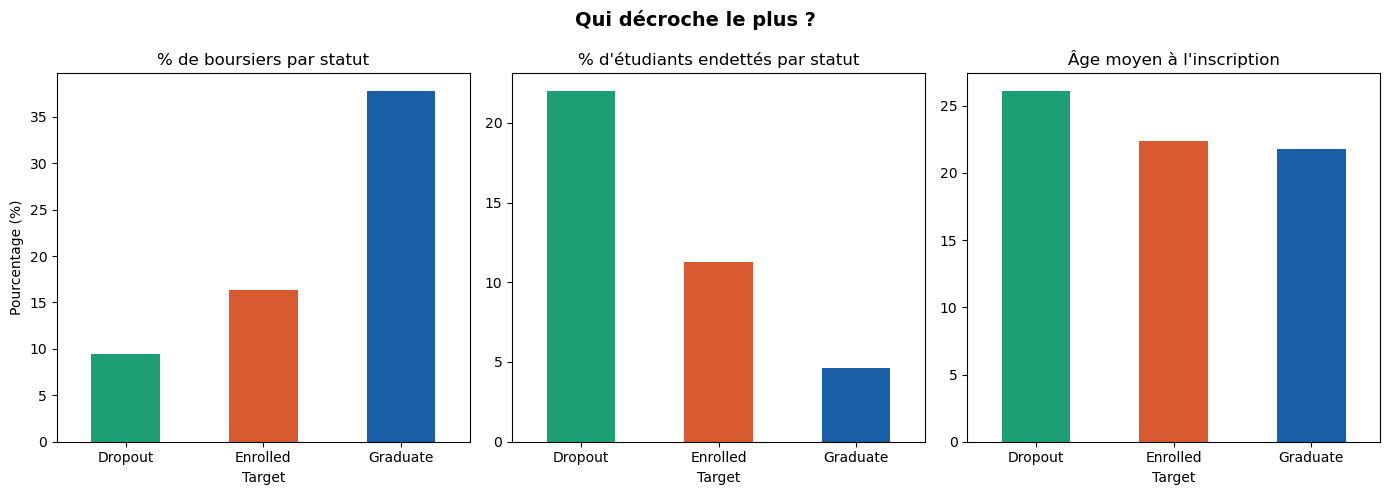

In [9]:
# Compare les décrocheurs vs diplômés sur 3 facteurs clés
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 1. Les boursiers décrochent-ils moins ?
df.groupby("Target")["Scholarship holder"].mean().mul(100).round(1).plot(
    kind="bar", ax=axes[0],
    color=["#1D9E75", "#D85A30", "#185FA5"],
    rot=0
)
axes[0].set_title("% de boursiers par statut")
axes[0].set_ylabel("Pourcentage (%)")

# 2. Les dettes influencent-elles le décrochage ?
df.groupby("Target")["Debtor"].mean().mul(100).round(1).plot(
    kind="bar", ax=axes[1],
    color=["#1D9E75", "#D85A30", "#185FA5"],
    rot=0
)
axes[1].set_title("% d'étudiants endettés par statut")

# 3. L'âge moyen à l'inscription
df.groupby("Target")["Age at enrollment"].mean().round(1).plot(
    kind="bar", ax=axes[2],
    color=["#1D9E75", "#D85A30", "#185FA5"],
    rot=0
)
axes[2].set_title("Âge moyen à l'inscription")

plt.suptitle("Qui décroche le plus ?", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_facteurs.png")
plt.show()

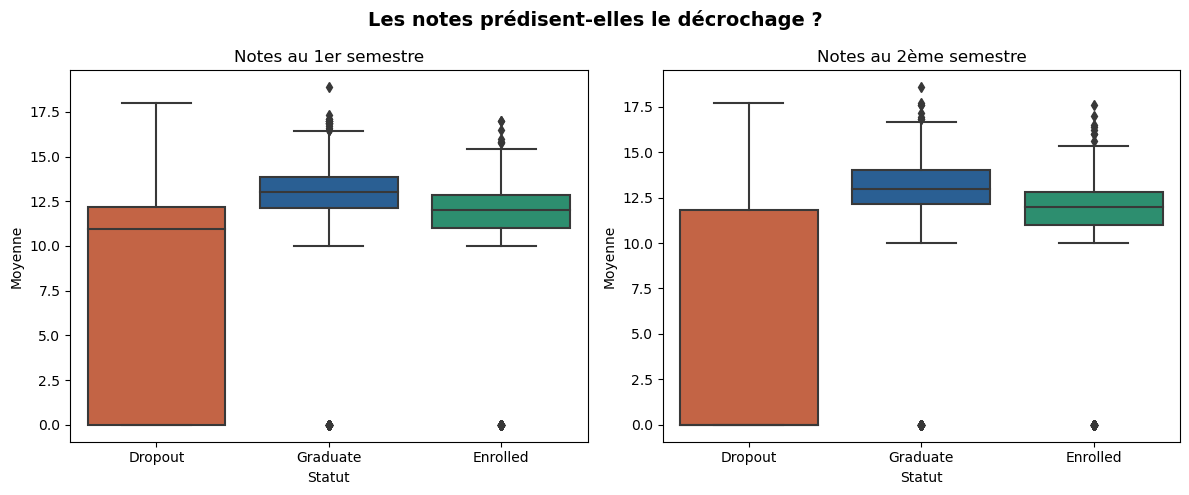

In [10]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Notes du 1er semestre
sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 1st sem (grade)",
    palette=["#D85A30", "#185FA5", "#1D9E75"],
    ax=axes[0]
)
axes[0].set_title("Notes au 1er semestre")
axes[0].set_xlabel("Statut")
axes[0].set_ylabel("Moyenne")

# Notes du 2ème semestre
sns.boxplot(
    data=df,
    x="Target",
    y="Curricular units 2nd sem (grade)",
    palette=["#D85A30", "#185FA5", "#1D9E75"],
    ax=axes[1]
)
axes[1].set_title("Notes au 2ème semestre")
axes[1].set_xlabel("Statut")
axes[1].set_ylabel("Moyenne")

plt.suptitle("Les notes prédisent-elles le décrochage ?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_notes.png")
plt.show()